# Sentiment Analysis for Retrieved X Posts
Use VADER sentiment (NLTK) to score each post from -1 (negative) to 1 (positive), without PyTorch.

In [1]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

CSV_PATH = "recent_tweets_elon_gavin.csv"

nltk.download("vader_lexicon", quiet=True)

df = pd.read_csv(CSV_PATH)
df = df.copy()
df[["id", "username", "text"]].head()

,id,username,text
0,2022219063020413410,elonmusk,Get stuff done @xAI https://t.co/ycsnLv5clK
1,2022213055355269446,elonmusk,Banger https://t.co/4r0EgKA4s9
2,2022200855915901205,elonmusk,Worse than the worst nightmare I could have im...
3,2022034584536555592,elonmusk,The most beautiful theorems \n https://t.co/BW...
4,2022032630221590983,elonmusk,6 years ago https://t.co/dDFaAo0BZS


In [2]:
sia = SentimentIntensityAnalyzer()


In [3]:
def score_to_minus1_plus1(text: str) -> float:
    text = "" if pd.isna(text) else str(text)
    sentiment = sia.polarity_scores(text)["compound"]
    if sentiment > 1.0:
        sentiment = 1.0
    elif sentiment < -1.0:
        sentiment = -1.0
    return float(sentiment)

df["sentiment_score"] = df["text"].apply(score_to_minus1_plus1)

df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0001, -0.2, 0.2, 1.0001],
    labels=["negative", "neutral", "positive"],
)

df[["username", "text", "sentiment_score", "sentiment_label"]].head(10)

,username,text,sentiment_score,sentiment_label
0,elonmusk,Get stuff done @xAI https://t.co/ycsnLv5clK,0.0000,neutral
1,elonmusk,Banger https://t.co/4r0EgKA4s9,0.0000,neutral
2,elonmusk,Worse than the worst nightmare I could have im...,-0.8020,negative
3,elonmusk,The most beautiful theorems \n https://t.co/BW...,0.6361,positive
4,elonmusk,6 years ago https://t.co/dDFaAo0BZS,0.0000,neutral
5,elonmusk,Only two more senators and America gets a new ...,0.0000,neutral
6,elonmusk,Not just anoether theorem. \n\nEverything foll...,0.0000,neutral
7,elonmusk,Grok gets jokes https://t.co/bW8KxUBxGR,0.2500,positive
8,elonmusk,𝕏 is the set of all things https://t.co/nwsyZF...,0.0000,neutral
9,elonmusk,Some good lists https://t.co/CetOrbrapi,0.4404,positive


## RoBERTa

In [4]:
import sys
import subprocess
import numpy as np
import pandas as pd
import nltk
from scipy.special import softmax
from scipy.stats import pearsonr, spearmanr
from nltk.sentiment import SentimentIntensityAnalyzer

# Ensure transformer dependencies are available in the notebook kernel
for pkg in ["transformers", "torch"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from transformers import AutoTokenizer, AutoModelForSequenceClassification

CSV_PATH = "recent_posts_1603.csv"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load data
comp_df = pd.read_csv(CSV_PATH).copy()
comp_df = comp_df.dropna(subset=["text"]).copy()
comp_df["text"] = comp_df["text"].astype(str)

# -------- VADER --------
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

def vader_label(score: float) -> str:
    if score <= -0.2:
        return "negative"
    if score >= 0.2:
        return "positive"
    return "neutral"

comp_df["vader_score"] = comp_df["text"].apply(lambda t: float(sia.polarity_scores(t)["compound"]))
comp_df["vader_label"] = comp_df["vader_score"].apply(vader_label)

# -------- RoBERTa --------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

def normalize_label(label: str) -> str:
    label = str(label).lower()
    if "neg" in label:
        return "negative"
    if "neu" in label:
        return "neutral"
    return "positive"

id2label = {int(k): normalize_label(v) for k, v in model.config.id2label.items()}
weights = np.array([{"negative": -1.0, "neutral": 0.0, "positive": 1.0}[id2label[i]] for i in range(len(id2label))])

def roberta_sentiment(text: str):
    encoded = tokenizer(text, truncation=True, max_length=512, return_tensors="pt")
    logits = model(**encoded).logits.detach().numpy()[0]
    probs = softmax(logits)
    label_idx = int(np.argmax(probs))
    label = id2label[label_idx]
    score = float(np.dot(probs, weights))
    return label, score

roberta_outputs = comp_df["text"].apply(roberta_sentiment)
comp_df["roberta_label"] = roberta_outputs.apply(lambda x: x[0])
comp_df["roberta_score"] = roberta_outputs.apply(lambda x: x[1])

# -------- Comparison --------
comp_df["label_match"] = comp_df["vader_label"] == comp_df["roberta_label"]
agreement = comp_df["label_match"].mean()

pearson_corr = pearsonr(comp_df["vader_score"], comp_df["roberta_score"])[0]
spearman_corr = spearmanr(comp_df["vader_score"], comp_df["roberta_score"]).correlation

print(f"Rows analyzed: {len(comp_df)}")
print(f"Label agreement (VADER vs RoBERTa): {agreement:.2%}")
print(f"Pearson correlation (scores): {pearson_corr:.4f}")
print(f"Spearman correlation (scores): {spearman_corr:.4f}")

print("\nConfusion matrix (rows=VADER, cols=RoBERTa):")
display(pd.crosstab(comp_df["vader_label"], comp_df["roberta_label"]))

if "spectrum" in comp_df.columns:
    by_spectrum = comp_df.groupby("spectrum", as_index=False).agg(
        posts=("id", "count"),
        vader_mean=("vader_score", "mean"),
        roberta_mean=("roberta_score", "mean"),
    )
    print("\nAverage sentiment by spectrum:")
    display(by_spectrum)

comp_df["score_abs_diff"] = (comp_df["vader_score"] - comp_df["roberta_score"]).abs()
print("\nTop 10 largest score disagreements:")
display(
    comp_df.sort_values("score_abs_diff", ascending=False)[
        ["name", "spectrum", "text", "vader_score", "vader_label", "roberta_score", "roberta_label", "score_abs_diff"]
    ].head(10)
    if "name" in comp_df.columns and "spectrum" in comp_df.columns
    else comp_df.sort_values("score_abs_diff", ascending=False)[
        ["text", "vader_score", "vader_label", "roberta_score", "roberta_label", "score_abs_diff"]
    ].head(10)
)

comp_df.head(5)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8958.85it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Rows analyzed: 97
Label agreement (VADER vs RoBERTa): 47.42%
Pearson correlation (scores): 0.4772
Spearman correlation (scores): 0.4473

Confusion matrix (rows=VADER, cols=RoBERTa):


roberta_label,negative,neutral,positive
vader_label,,,
negative,21,15,4
neutral,11,12,2
positive,7,12,13



Average sentiment by spectrum:


,spectrum,posts,vader_mean,roberta_mean
0,C,56,-0.078229,-0.131578
1,L,41,-0.125320,-0.196256



Top 10 largest score disagreements:


,name,spectrum,text,vader_score,vader_label,roberta_score,roberta_label,score_abs_diff
52,Myron Gaines,C,Watching zionists complain about getting a tas...,0.6044,positive,-0.935376,negative,1.539776
73,hasanabi,L,every top democrat has an opportunity to let t...,0.7170,positive,-0.704741,negative,1.421741
76,hasanabi,L,war effort status: going well! https://t.co/wP...,-0.4753,negative,0.850473,positive,1.325773
74,hasanabi,L,this is the most popular israel will ever be i...,0.8396,positive,-0.288342,negative,1.127942
91,Jackson Hinkle,L,"🚨🇺🇸🇮🇷 NOW: TRUMP claims ""Iran is a nation of G...",-0.7096,negative,0.405497,positive,1.115097
90,Jackson Hinkle,L,🚨🇺🇸🇮🇷 TRUMP: “IRAN is a nation of…GREAT POWER…...,-0.4767,negative,0.614062,positive,1.090762
41,Alex Jones,C,Tune In Live! Founder Of The J6 Pardon Project...,-0.4646,negative,0.551861,positive,1.016461
57,GavinNewsom,L,Fox News refuses to report the truth:\n\nTexas...,0.3182,positive,-0.674595,negative,0.992795
26,Libs of TikTok,C,"""Iran, I just want to straight up tell you thi...",0.2960,positive,-0.683810,negative,0.979810
89,Jackson Hinkle,L,🚀🇮🇷🇺🇸🇮🇱 LIVE AT 3PM ET: IRAN STRIKES DEVASTATE...,-0.9000,negative,0.048099,neutral,0.948099


,id,text,author_id,public_metrics,created_at,name,spectrum,vader_score,vader_label,roberta_label,roberta_score,label_match,score_abs_diff
0,2033530483804717405,Oscars have become unwatchable https://t.co/dg...,44196397,"{'retweet_count': 12942, 'reply_count': 7957, ...",2026-03-16T13:07:03.000Z,Elon,C,0.0,neutral,negative,-0.762079,False,0.762079
1,2033442939796681132,Grok Imagine triple gold 🥇🥇🥇 https://t.co/F97b...,44196397,"{'retweet_count': 4243, 'reply_count': 3207, '...",2026-03-16T07:19:11.000Z,Elon,C,0.0,neutral,positive,0.836672,False,0.836672
2,2033441907741995186,Starlink available in Central African Republic...,44196397,"{'retweet_count': 6755, 'reply_count': 6293, '...",2026-03-16T07:15:04.000Z,Elon,C,0.0,neutral,neutral,0.056166,True,0.056166
3,2033410934170153087,Grok https://t.co/KLy3YOdsvd,44196397,"{'retweet_count': 2138, 'reply_count': 1961, '...",2026-03-16T05:12:00.000Z,Elon,C,0.0,neutral,neutral,0.005381,True,0.005381
4,2033383517674221595,Grok https://t.co/X9t4UTEPMl,44196397,"{'retweet_count': 9408, 'reply_count': 3089, '...",2026-03-16T03:23:03.000Z,Elon,C,0.0,neutral,neutral,0.011377,True,0.011377


In [5]:
half_n = len(comp_df) // 2
roberta_cols = [
    col for col in [
        "id",
        "name",
        "spectrum",
        "text",
        "roberta_score",
        "roberta_label",
        "vader_score",
        "vader_label",
        "label_match",
    ] if col in comp_df.columns
]

print(f"Showing first half of RoBERTa-classified rows: {half_n} of {len(comp_df)}")
comp_df.loc[:, roberta_cols].head(half_n)

Showing first half of RoBERTa-classified rows: 48 of 97


,id,name,spectrum,text,roberta_score,roberta_label,vader_score,vader_label,label_match
0,2033530483804717405,Elon,C,Oscars have become unwatchable https://t.co/dg...,-0.762079,negative,0.0000,neutral,False
1,2033442939796681132,Elon,C,Grok Imagine triple gold 🥇🥇🥇 https://t.co/F97b...,0.836672,positive,0.0000,neutral,False
2,2033441907741995186,Elon,C,Starlink available in Central African Republic...,0.056166,neutral,0.0000,neutral,True
3,2033410934170153087,Elon,C,Grok https://t.co/KLy3YOdsvd,0.005381,neutral,0.0000,neutral,True
4,2033383517674221595,Elon,C,Grok https://t.co/X9t4UTEPMl,0.011377,neutral,0.0000,neutral,True
5,2033378365516947545,Nick shirley,C,As promised to my subscribers I posted a trail...,0.888826,positive,0.3682,positive,True
6,2033360347122504017,Nick shirley,C,Join here (hoodie is also available here)\nhtt...,0.361800,neutral,0.2960,positive,False
7,2033357793412178075,Nick shirley,C,Anti Fraud Taxpayer Club https://t.co/1sNXcQG61r,-0.363268,neutral,-0.7269,negative,False
8,2033557143631048827,Ron DeSantis,C,Florida has led on election integrity for year...,0.859906,positive,0.3034,positive,True
9,2033546192068472878,Ron DeSantis,C,Happy birthday to the Father of the Constituti...,0.927944,positive,0.7841,positive,True


In [4]:
summary = (
    df.groupby("username", as_index=False)["sentiment_score"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)
summary

OUTPUT_PATH = "recent_tweets_elon_gavin_with_sentiment.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

Saved: recent_tweets_elon_gavin_with_sentiment.csv


## Sentiment Visualizations
Bar charts for average sentiment by user and sentiment label counts by user.

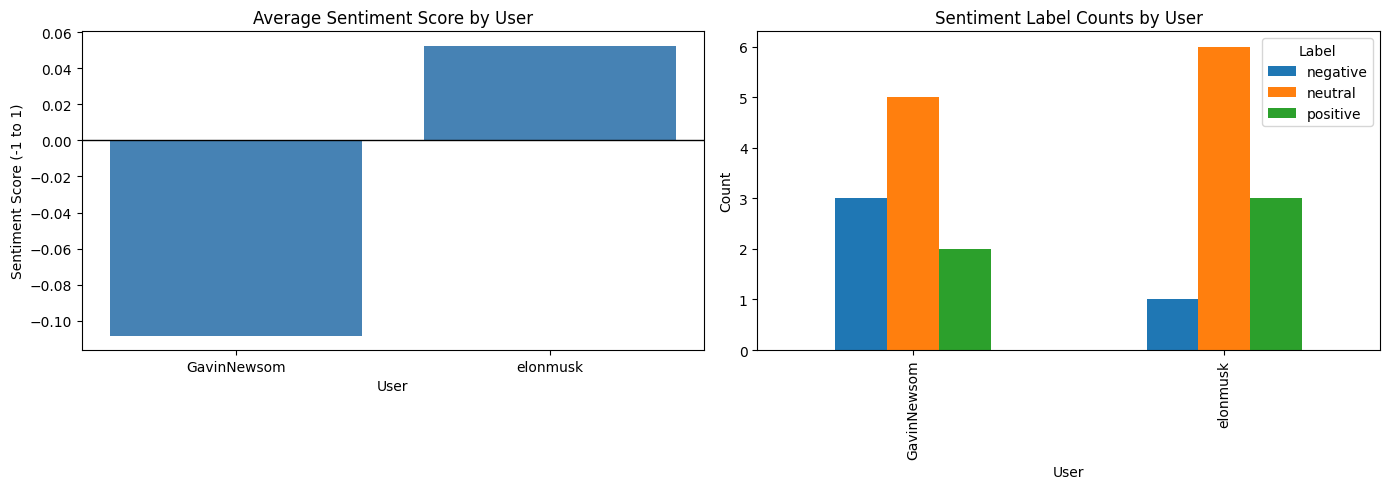

In [5]:
import matplotlib.pyplot as plt

avg_sentiment = df.groupby("username", as_index=False)["sentiment_score"].mean()
label_counts = (
    df.groupby(["username", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(avg_sentiment["username"], avg_sentiment["sentiment_score"], color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average Sentiment Score by User")
axes[0].set_ylabel("Sentiment Score (-1 to 1)")
axes[0].set_xlabel("User")

label_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sentiment Label Counts by User")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("User")
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

## Senator's Tweets

In [6]:
import pandas as pd

TRAIN_PATH = "train-00000-of-00001.parquet"

train_df = pd.read_parquet(TRAIN_PATH)

print(f"Loaded training examples: {train_df.shape[0]} rows x {train_df.shape[1]} columns")
print("Columns:", train_df.columns.tolist())

train_df.head(10)

Loaded training examples: 79754 rows x 7 columns
Columns: ['date', 'id', 'username', 'text', 'party', 'labels', 'embeddings']


,date,id,username,text,party,labels,embeddings
0,2021-10-13 19:47:44,1448374915636383745,SenatorHassan,Happy th birthday to the @USNavy! The strength...,Democrat,1,"[-0.026915843, 0.087234065, 0.018707331, -0.03..."
1,2021-06-30 14:53:13,1410250073003462656,SenatorMenendez,The greatest generation's investment in infras...,Democrat,1,"[0.024044158, -0.0048382296, 0.09699756, -0.03..."
2,2021-08-08 01:11:29,1424176405881966599,SenBillCassidy,"Thanks to @SenTedCruz and @SenatorWarnock, th...",Republican,0,"[-0.002620128, -0.042515174, 0.065084696, 0.01..."
3,2021-04-14 14:02:49,1382333523567185921,SenBlumenthal,/ To get lasting change we cant just lock up t...,Democrat,1,"[-0.045103785, 0.0762336, -0.011798679, -0.044..."
4,2021-12-11 16:06:38,1469700160934621188,SenatorBraun,Today were celebrating years of the Hoosier st...,Republican,0,"[-0.038810886, 0.11611319, 0.06621017, -0.0184..."
5,2021-05-11 17:18:50,1392167324401143812,SenJeffMerkley,The #ForthePeopleAct includes reforms that are...,Democrat,1,"[-0.028889425, -0.04910916, 0.007949473, -0.06..."
6,2021-08-10 16:22:55,1425130548620578816,SenBlumenthal,"Todays strong, bipartisan vote is just the beg...",Democrat,1,"[0.015318287, -0.091730736, 0.029860392, -0.05..."
7,2021-08-12 01:13:26,1425626448518385664,SenatorHagerty,Supporting crime victims requires holding crim...,Republican,0,"[-0.031652693, -0.015171198, 0.028115185, 0.02..."
8,2021-12-11 16:27:51,1469705498224209928,SenBillCassidy,We in Louisiana know how natural disasters cha...,Republican,0,"[-0.019437807, -0.059072897, 0.13377255, -0.01..."
9,2021-01-20 13:55:04,1351890994220957698,CoryBooker,Today we start anew.,Democrat,1,"[-0.044110484, -0.019089103, 0.009209107, 0.03..."


## Text-Only Party Classifier
Train a model using only tweet text to classify each tweet as Democrat or Republican.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf_df = train_df[["text", "party"]].dropna().copy()
clf_df["text"] = clf_df["text"].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    clf_df["text"],
    clf_df["party"],
    test_size=0.2,
    random_state=42,
    stratify=clf_df["party"],
)

text_clf = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 3), min_df=5)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, solver="liblinear")),
    ]
)

text_clf.fit(X_train, y_train)
y_pred = text_clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"Validation accuracy: {acc:.4f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, y_pred, labels=["Democrat", "Republican"]))
print("\nClassification report:")
print(classification_report(y_val, y_pred, digits=4))

Validation accuracy: 0.8689

Confusion matrix (rows=true, cols=pred):
[[7136 1062]
 [1029 6724]]

Classification report:
              precision    recall  f1-score   support

    Democrat     0.8740    0.8705    0.8722      8198
  Republican     0.8636    0.8673    0.8654      7753

    accuracy                         0.8689     15951
   macro avg     0.8688    0.8689    0.8688     15951
weighted avg     0.8689    0.8689    0.8689     15951



In [8]:
sample_preds = pd.DataFrame({
    "text": X_val.iloc[:10].values,
    "true_party": y_val.iloc[:10].values,
    "pred_party": y_pred[:10],
})
sample_preds

,text,true_party,pred_party
0,House Democrats are panning Sen. RON WYDENs (D...,Republican,Republican
1,"For the first time since early , DHS has a Sen...",Democrat,Democrat
2,Not only is the bipartisan Infrastructure Inve...,Democrat,Democrat
3,The truth you wont hear from the president ton...,Republican,Republican
4,Mayor Gerlach has spent over two decades servi...,Republican,Republican
5,"While in Talkeetna, I met with Israel Mahay, o...",Republican,Republican
6,The steadfast love of the Lord never ceases; H...,Republican,Republican
7,Apparently this guy has to carry a spear to pr...,Democrat,Democrat
8,The #BidenBorderCrisis is putting Texas commun...,Republican,Republican
9,The TRIO program is proven to help students pr...,Democrat,Democrat


In [9]:
misclassified = pd.DataFrame({
    "text": X_val.values,
    "true_party": y_val.values,
    "pred_party": y_pred,
})

misclassified = misclassified[misclassified["true_party"] != misclassified["pred_party"]].copy()
misclassified["text_len"] = misclassified["text"].str.len()

print(f"Misclassified examples: {len(misclassified)}")
misclassified.sample(min(20, len(misclassified)), random_state=42) if len(misclassified) > 0 else misclassified

Misclassified examples: 2091


,text,true_party,pred_party,text_len
14860,The National Right to Work Act ensures all wor...,Republican,Democrat,217
250,Really excited about the amendment I put forwa...,Democrat,Republican,277
1526,El pueblo Colombiano tiene que tener el derech...,Democrat,Republican,266
7166,Today I visited South Central Regional Medical...,Republican,Democrat,302
4228,"Honored to attend tonights #JointAddress, even...",Democrat,Republican,109
12282,UPDATE: Boulder police issued a correction for...,Democrat,Republican,105
9423,America needs a Green Bank - a national financ...,Democrat,Republican,251
396,"Something that is actually demonstrably, laugh...",Democrat,Republican,81
4831,Our @CTNationalGuard and other CT servicememb...,Democrat,Republican,284
4671,"On #WorldCancerDay, were working to advance ca...",Democrat,Republican,127


In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [2, 5, 10],
    "tfidf__max_df": [0.9, 1.0],
    "model__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=text_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

best_text_clf = grid.best_estimator_
best_pred = best_text_clf.predict(X_val)

print("Best CV score (f1_macro):", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)
print(f"Validation accuracy (best model): {accuracy_score(y_val, best_pred):.4f}")
print("\nValidation classification report (best model):")
print(classification_report(y_val, best_pred, digits=4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV score (f1_macro): 0.8602
Best params: {'model__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Validation accuracy (best model): 0.8687

Validation classification report (best model):
              precision    recall  f1-score   support

    Democrat     0.8746    0.8690    0.8718      8198
  Republican     0.8624    0.8683    0.8654      7753

    accuracy                         0.8687     15951
   macro avg     0.8685    0.8687    0.8686     15951
weighted avg     0.8687    0.8687    0.8687     15951



## Current Tweets

Train a text-only classifier on historical tweets with `spectrum` target (`C` vs `L`), then predict spectrum on the fetched current posts.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train/validate directly on the new dataset
CURRENT_POSTS_PATH = "recent_posts_from_ids.csv"
current_df = pd.read_csv(CURRENT_POSTS_PATH)
current_df = current_df.dropna(subset=["text", "spectrum"]).copy()
current_df["text"] = current_df["text"].astype(str)
current_df["spectrum"] = current_df["spectrum"].astype(str).str.strip()

# Keep only known target classes
current_df = current_df[current_df["spectrum"].isin(["C", "L"])].copy()

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    current_df["text"],
    current_df["spectrum"],
    test_size=0.2,
    random_state=42,
    stratify=current_df["spectrum"],
)

spectrum_clf = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]
)

spectrum_clf.fit(X_train_s, y_train_s)
y_val_s_pred = spectrum_clf.predict(X_val_s)

print(f"Validation accuracy (spectrum C/L): {accuracy_score(y_val_s, y_val_s_pred):.4f}")
print("\nConfusion matrix (rows=true, cols=pred) for [C, L]:")
print(confusion_matrix(y_val_s, y_val_s_pred, labels=["C", "L"]))
print("\nClassification report:")
print(classification_report(y_val_s, y_val_s_pred, digits=4))

val_results = pd.DataFrame({
    "text": X_val_s.values,
    "true_spectrum": y_val_s.values,
    "pred_spectrum": y_val_s_pred,
})
val_results["correct"] = val_results["true_spectrum"] == val_results["pred_spectrum"]

print("\nPredicted class counts on validation:")
print(val_results["pred_spectrum"].value_counts())

val_results.head(20)

Validation accuracy (spectrum C/L): 0.7656

Confusion matrix (rows=true, cols=pred) for [C, L]:
[[49 17]
 [13 49]]

Classification report:
              precision    recall  f1-score   support

           C     0.7903    0.7424    0.7656        66
           L     0.7424    0.7903    0.7656        62

    accuracy                         0.7656       128
   macro avg     0.7664    0.7664    0.7656       128
weighted avg     0.7671    0.7656    0.7656       128


Predicted class counts on validation:
pred_spectrum
L    66
C    62
Name: count, dtype: int64


,text,true_spectrum,pred_spectrum,correct
0,"Q: What about the $2,000 checks you promised?\...",L,L,True
1,Donald Trump’s actions in Venezuela do not mak...,L,L,True
2,Chaos spreads like cancer in Minneapolis. What...,C,C,True
3,Bad Bunny was the right choice. Great performa...,L,C,False
4,Jeff Bezos is spending $200 billion on AI and ...,L,C,False
5,His account of Eskimo culture is pretty fascin...,C,C,True
6,Recreational use only. https://t.co/u98huxuUc7,C,C,True
7,"🚨🇨🇳 BREAKING: The Pentagon added, then suddden...",L,L,True
8,Let’s have a little sympathy for the strugglin...,L,L,True
9,🚨I am proud to be on the official Epstein list...,C,C,True


In [12]:
import re
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

CURRENT_POSTS_PATH = "recent_posts_from_ids.csv"
topics_df = pd.read_csv(CURRENT_POSTS_PATH)
topics_df = topics_df.dropna(subset=["text"]).copy()
topics_df["text"] = topics_df["text"].astype(str)

# Remove URLs before vectorization
url_pattern = re.compile(r"https?://\S+|www\.\S+")
topics_df["clean_text"] = topics_df["text"].str.replace(url_pattern, " ", regex=True).str.strip()

print(f"Analyzing {len(topics_df)} tweets for topic trends")

# 1) Most frequent discussion phrases (unigrams/bigrams)
count_vec = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=3000,
    lowercase=True,
)

X_count = count_vec.fit_transform(topics_df["clean_text"])
ngram_counts = X_count.sum(axis=0).A1
ngram_terms = count_vec.get_feature_names_out()

top_n = 25
top_idx = ngram_counts.argsort()[::-1][:top_n]
top_phrases = pd.DataFrame({
    "phrase": ngram_terms[top_idx],
    "count": ngram_counts[top_idx],
})

print("\nTop recurring terms/phrases:")
display(top_phrases)

# 2) Topic modeling (NMF on TF-IDF)
tfidf_vec = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=4000,
    lowercase=True,
)

X_tfidf = tfidf_vec.fit_transform(topics_df["clean_text"])
num_topics = 6
nmf = NMF(n_components=num_topics, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_
terms = tfidf_vec.get_feature_names_out()

topic_keywords = []
for topic_idx, weights in enumerate(H):
    top_term_idx = weights.argsort()[::-1][:8]
    keywords = [terms[i] for i in top_term_idx]
    topic_keywords.append({
        "topic": f"Topic {topic_idx + 1}",
        "keywords": ", ".join(keywords),
    })

topics_summary = pd.DataFrame(topic_keywords)

dominant_topic_idx = W.argmax(axis=1)
topics_df["dominant_topic"] = [f"Topic {idx + 1}" for idx in dominant_topic_idx]
topic_volume = topics_df["dominant_topic"].value_counts().rename_axis("topic").reset_index(name="tweet_count")

print("\nTop discussion topics (NMF keywords):")
display(topics_summary)

print("\nTopic volume (most present topics):")
display(topic_volume)

Analyzing 636 tweets for topic trends

Top recurring terms/phrases:


,phrase,count
0,trump,101
1,just,52
2,epstein,52
3,people,52
4,ice,51
5,new,39
6,today,37
7,files,34
8,breaking,33
9,american,30



Top discussion topics (NMF keywords):


,topic,keywords
0,Topic 1,"trump, donald, donald trump, video, american, ..."
1,Topic 2,"help, lower costs, lower, costs, continue deli..."
2,Topic 3,"bad, bad bunny, bunny, happy, love, day, valen..."
3,Topic 4,"epstein, files, epstein files, bondi, pam bond..."
4,Topic 5,"ice, people, country, new, breaking, amp, just..."
5,Topic 6,"code, code tucker, tucker, use, paid partnersh..."



Topic volume (most present topics):


,topic,tweet_count
0,Topic 5,340
1,Topic 1,125
2,Topic 3,66
3,Topic 4,57
4,Topic 6,25
5,Topic 2,23


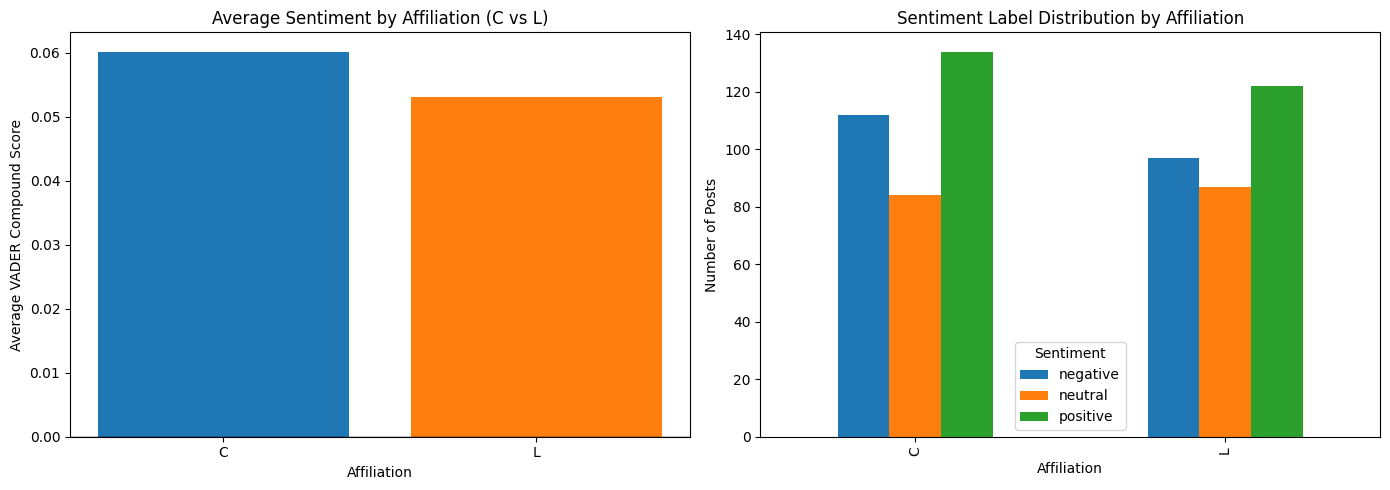

A Welch t-test found no statistically significant difference in mean sentiment between C and L posts (t=0.161, p=0.8722).


,spectrum,sentiment_score
0,C,0.060210
1,L,0.053048


In [14]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from nltk.sentiment import SentimentIntensityAnalyzer

RECENT_POSTS_PATH = "recent_posts_from_ids.csv"

nltk.download("vader_lexicon", quiet=True)
sia_recent = SentimentIntensityAnalyzer()

recent_df = pd.read_csv(RECENT_POSTS_PATH)
recent_df = recent_df.dropna(subset=["text", "spectrum"]).copy()
recent_df["text"] = recent_df["text"].astype(str)
recent_df["spectrum"] = recent_df["spectrum"].astype(str).str.strip()
recent_df = recent_df[recent_df["spectrum"].isin(["C", "L"])].copy()

recent_df["sentiment_score"] = recent_df["text"].apply(
    lambda text: float(sia_recent.polarity_scores(text)["compound"])
)

recent_df["sentiment_label"] = pd.cut(
    recent_df["sentiment_score"],
    bins=[-1.0001, -0.2, 0.2, 1.0001],
    labels=["negative", "neutral", "positive"],
)

sentiment_by_spectrum = (
    recent_df.groupby("spectrum", as_index=False)["sentiment_score"]
    .mean()
    .sort_values("spectrum")
)

label_counts_by_spectrum = (
    recent_df.groupby(["spectrum", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["C", "L"], fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    sentiment_by_spectrum["spectrum"],
    sentiment_by_spectrum["sentiment_score"],
    color=["#1f77b4", "#ff7f0e"],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average Sentiment by Affiliation (C vs L)")
axes[0].set_xlabel("Affiliation")
axes[0].set_ylabel("Average VADER Compound Score")

label_counts_by_spectrum.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sentiment Label Distribution by Affiliation")
axes[1].set_xlabel("Affiliation")
axes[1].set_ylabel("Number of Posts")
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

c_scores = recent_df.loc[recent_df["spectrum"] == "C", "sentiment_score"]
l_scores = recent_df.loc[recent_df["spectrum"] == "L", "sentiment_score"]
t_stat, p_value = ttest_ind(c_scores, l_scores, equal_var=False, nan_policy="omit")

print(
    f"A Welch t-test found {'a statistically significant' if p_value < 0.05 else 'no statistically significant'} difference in mean sentiment between C and L posts (t={t_stat:.3f}, p={p_value:.4f})."
)

sentiment_by_spectrum